<a href="https://colab.research.google.com/github/mcarden4-netizen/Homework-Intro-to-ML/blob/Homework/Homework3Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
drive.mount('/content/drive')

filetest = '/content/drive/My Drive/Cancer.csv'
data = pd.DataFrame(pd.read_csv(filetest))
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [57]:
#2.1

X = data.drop(['id', 'diagnosis', 'Unnamed: 32'], axis=1)
Y = (data['diagnosis'] == 'M').astype(int)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, random_state=50, stratify=Y)

scaler = StandardScaler()
Xtrain = scaler.fit_transform(Xtrain)
Xtest = scaler.transform(Xtest)

In [58]:
Xtrain = np.c_[np.ones(Xtrain.shape[0]), Xtrain]
Xtest = np.c_[np.ones(Xtest.shape[0]), Xtest]

Ytrain = Ytrain.values
Ytest = Ytest.values

In [59]:
def sigmoid(z):

  z = np.clip(z, -500, 500)
  formula = 1 / (1 + np.exp(-z))

  return formula

In [60]:
def Calculate_loss(Input_data, Output_data, Theta):

  B = len(Output_data)

  predictions = sigmoid(Input_data.dot(Theta))

  eps = 1e-15

  predictions = np.clip(predictions, eps, 1 - eps)

  loss = -(1/B) * np.sum(Output_data * np.log(predictions) + (1 - Output_data) * np.log(1 - predictions))

  return loss

In [61]:
def gradient_descent(Input_data, Output_data, Theta, Alpha, instances):

  B = len(Output_data)

  loss_history = np.zeros(instances)
  accuracy_history = np.zeros(instances)

  for i in range(instances):

    predictions = sigmoid(Input_data.dot(Theta))

    errors = predictions - Output_data

    gradient = (1/B) * (Input_data.T.dot(errors))

    Theta -= Alpha * gradient

    loss_history[i] = Calculate_loss(Input_data, Output_data, Theta)

    training_pred = (sigmoid(Input_data.dot(Theta)) >= 0.5).astype(int)
    accuracy_history[i] = accuracy_score(Output_data, training_pred)

  return Theta, loss_history, accuracy_history

In [62]:
theta = np.zeros(Xtrain.shape[1])
alpha = .05
iterations = 1500

In [63]:
theta, loss_history, accuracy_history = gradient_descent(Xtrain, Ytrain, theta, alpha, iterations)

/tmp/ipykernel_1376/1824866085.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


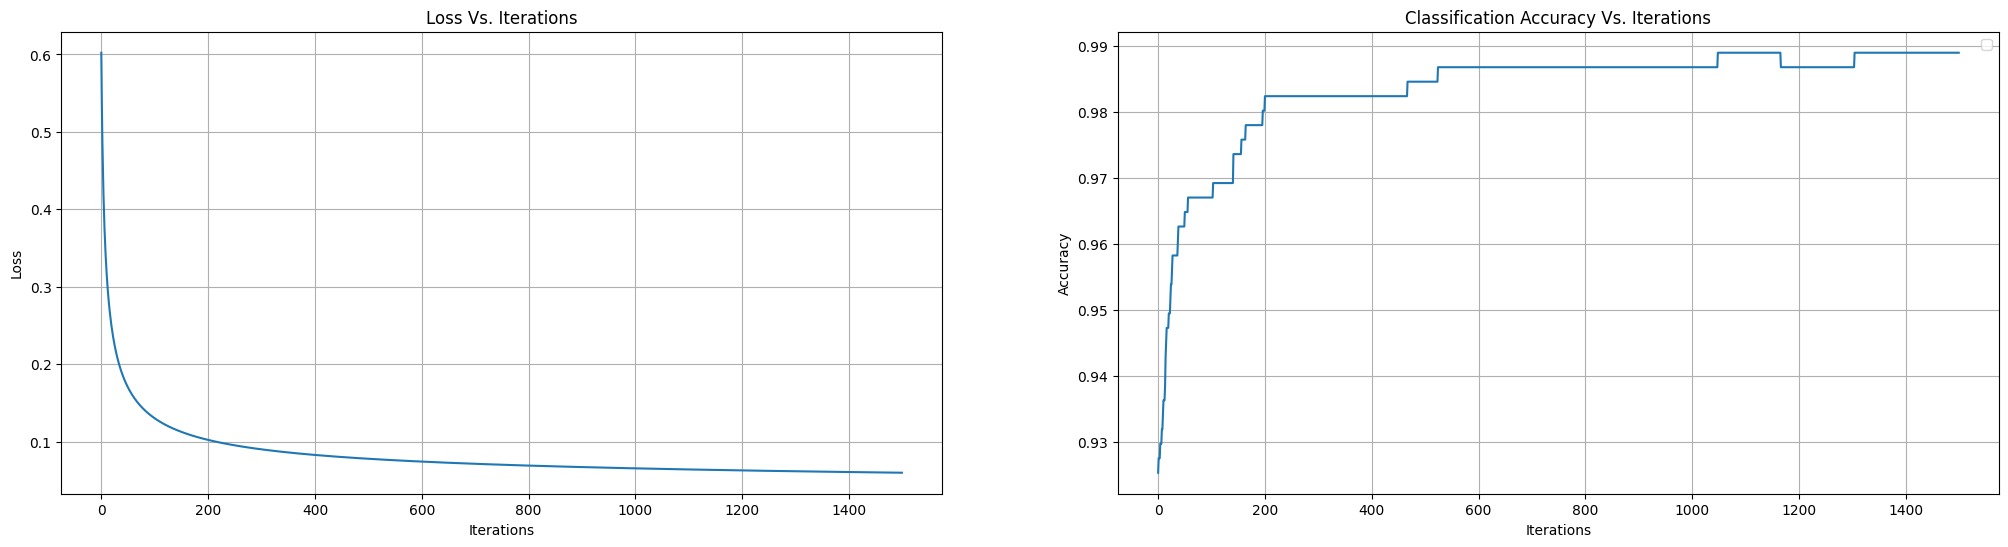

In [64]:
plt.figure(figsize=(25,6))

plt.subplot(1,2,1)
plt.plot(loss_history)
plt.grid(True)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss Vs. Iterations')

plt.subplot(1,2,2)
plt.plot(accuracy_history)
plt.grid(True)
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.title('Classification Accuracy Vs. Iterations')
plt.legend()

In [65]:
testp = sigmoid(Xtest.dot(theta))
Ypred = (testp >= 0.5).astype(int)

In [66]:
accuracy = accuracy_score(Ytest, Ypred)
precision = precision_score(Ytest, Ypred)
recall = recall_score(Ytest, Ypred)
f1 = f1_score(Ytest, Ypred)

In [67]:
print(f'Accuracy = {accuracy}')
print(f'Precision = {precision}')
print(f'Recall = {recall}')
print(f'F1 Score = {f1}')
print(f'Training loss =', loss_history[-1])
print(f'Training accuracy =', accuracy_history[-1])

Accuracy = 0.9824561403508771
Precision = 1.0
Recall = 0.9523809523809523
F1 Score = 0.975609756097561
Training loss = 0.05969591250026137
Training accuracy = 0.989010989010989


In [68]:
Job = confusion_matrix(Ytest, Ypred)

print(Job)

[[72  0]
 [ 2 40]]


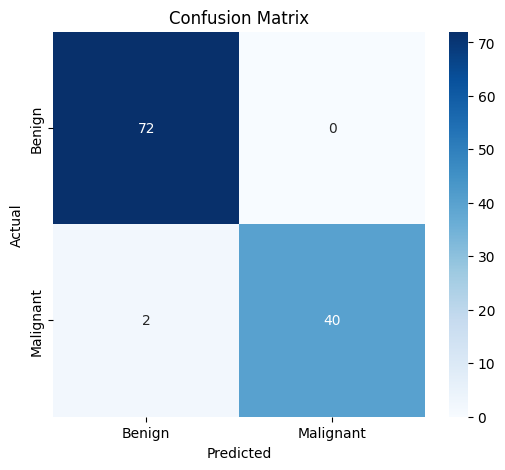

In [69]:
plt.figure(figsize=(6, 5))

sns.heatmap(Job, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [70]:
#2.2

def loss_penalty(Input_data, Output_data, Theta, Lambda):
  loss = Calculate_loss(Input_data, Output_data, Theta)
  penalty = (Lambda / (2 * len(Output_data))) * np.sum(Theta[1:]**2)

  overall = loss + penalty

  return overall

In [71]:

def gdp(Input_data, Output_data, Theta, Alpha, Instances, Lambda):

  B = len(Output_data)

  loss_history = np.zeros(Instances)
  accuracy_history = np.zeros(Instances)

  for i in range(Instances):

    predictions = sigmoid(Input_data.dot(Theta))

    errors = predictions - Output_data

    gradient = (1/B) * (Input_data.T.dot(errors))

    gradient[1:] += (Lambda / B) * Theta[1:]

    Theta -= Alpha * gradient

    loss_history[i] = loss_penalty(Input_data, Output_data, Theta, Lambda)

    training_pred = (sigmoid(Input_data.dot(Theta)) >= 0.5).astype(int)
    accuracy_history[i] = accuracy_score(Output_data, training_pred)

  return Theta, loss_history, accuracy_history

In [72]:
newtheta = np.zeros(Xtrain.shape[1])
newalpha = .08
newiterations = 1500
Lambda = 1

newtheta, newloss_history, newaccuracy_history = gdp(Xtrain, Ytrain, newtheta, newalpha, newiterations, Lambda)

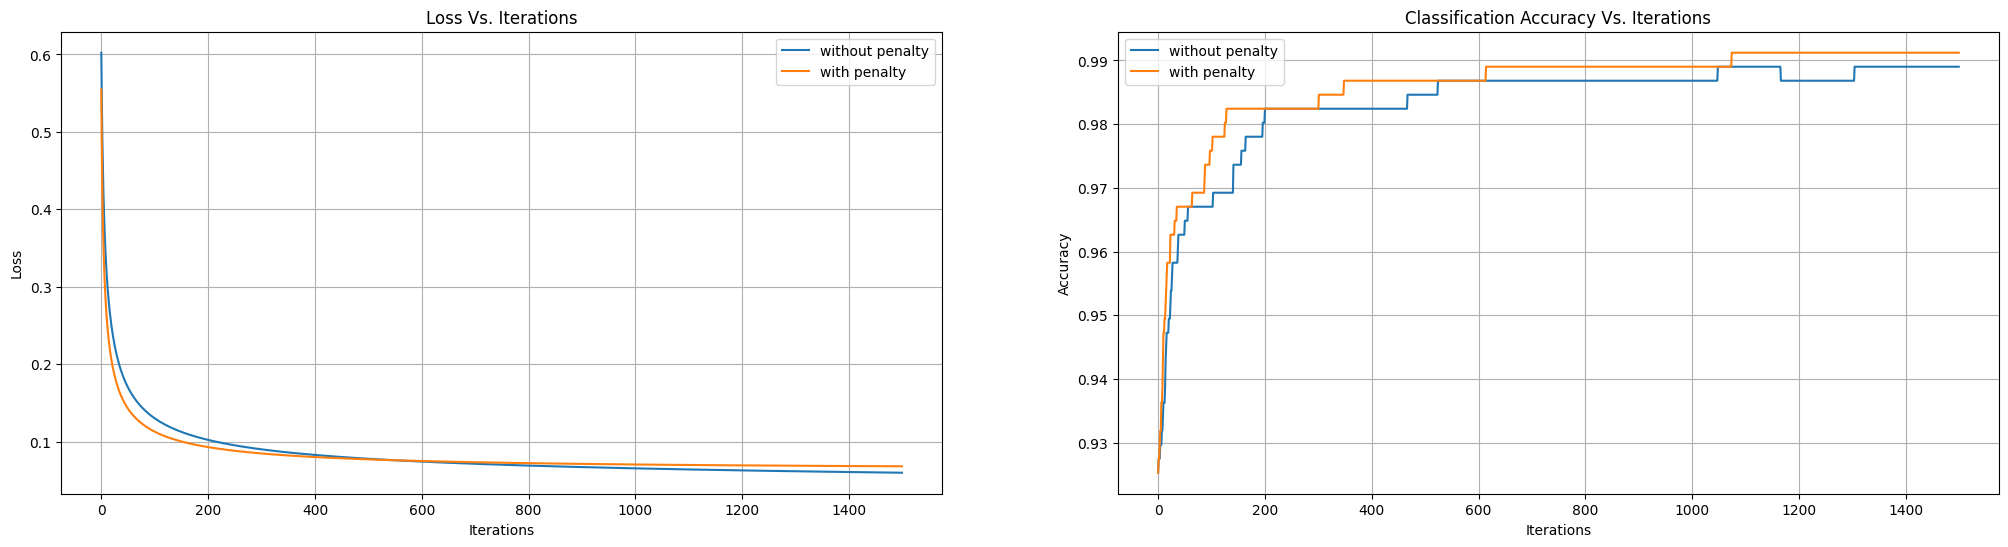

In [73]:
plt.figure(figsize=(25,6))

plt.subplot(1,2,1)
plt.plot(loss_history, label ='without penalty')
plt.plot(newloss_history,label ='with penalty')
plt.grid(True)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss Vs. Iterations')
plt.legend()

plt.subplot(1,2,2)
plt.plot(accuracy_history, label ='without penalty')
plt.plot(newaccuracy_history,label ='with penalty')
plt.grid(True)
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.title('Classification Accuracy Vs. Iterations')
plt.legend()

In [74]:
testp = sigmoid(Xtest.dot(newtheta))
Ypredp = (testp >= 0.5).astype(int)

In [75]:
accuracyp = accuracy_score(Ytest, Ypredp)
precisionp = precision_score(Ytest, Ypredp)
recallp = recall_score(Ytest, Ypredp)
f1p = f1_score(Ytest, Ypredp)

In [76]:
print(f'Accuracy = {accuracyp}')
print(f'Precision = {precisionp}')
print(f'Recall = {recallp}')
print(f'F1 Score = {f1p}')
print(f'Training loss =', newloss_history[-1])
print(f'Training accuracy =', newaccuracy_history[-1])

Accuracy = 0.9824561403508771
Precision = 1.0
Recall = 0.9523809523809523
F1 Score = 0.975609756097561
Training loss = 0.06802396765002294
Training accuracy = 0.9912087912087912


In [77]:
Jobp = confusion_matrix(Ytest, Ypredp)

print(Job)

[[72  0]
 [ 2 40]]


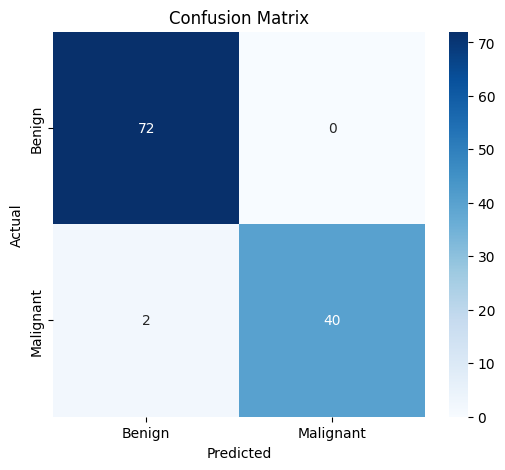

In [78]:
plt.figure(figsize=(6, 5))

sns.heatmap(Jobp, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()